In [1]:
from src.utils import get_data_env
from src.models import GATv2Model
from src.dataloading import DeepDataLoader

measles_nodes = [3,8, 17, 28, 36]

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-05-01 (+2 weeks)

==Training spatial gnn - identity_graph==
Epoch 1 train loss: 2.2726, val loss: 1.2352 ✓ (new best)
Epoch 2 train loss: 1.9328, val loss: 1.1324 ✓ (new best)
Epoch 3 train loss: 1.6288, val loss: 1.1910 (patience: 1/20)
Epoch 4 train loss: 1.5246, val loss: 1.0228 ✓ (new best)
Epoch 5 train loss: 1.3913, val loss: 0.9926 ✓ (new best)
Epoch 6 train loss: 1.3714, val loss: 0.9271 ✓ (new best)
Epoch 7 train loss: 1.3118, val loss: 0.9766 (patience: 1/20)
Epoch 8 train loss: 1.2729, val loss: 0.9383 (patience: 2/20)
Epoch 9 train loss: 1.2328, val loss: 0.9876 (patience: 3/20)
Epoch 10 train loss: 1.1849, val loss: 0.9335 (patience: 4/20)
Epoch 11 train loss: 1.2149, val loss: 0.9286 (patience: 5/20)
Epoch 12 train loss: 1.1458, val loss: 0.9368 (patience: 6/20)
lr has been updated from 0.00005 to 0.00004
Epoch 13 train loss: 1.2013, val loss: 0.9458 (patience: 7/20)
Epoch 14 train loss: 1.13

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 542.03it/s]


Test loss: 0.4969


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

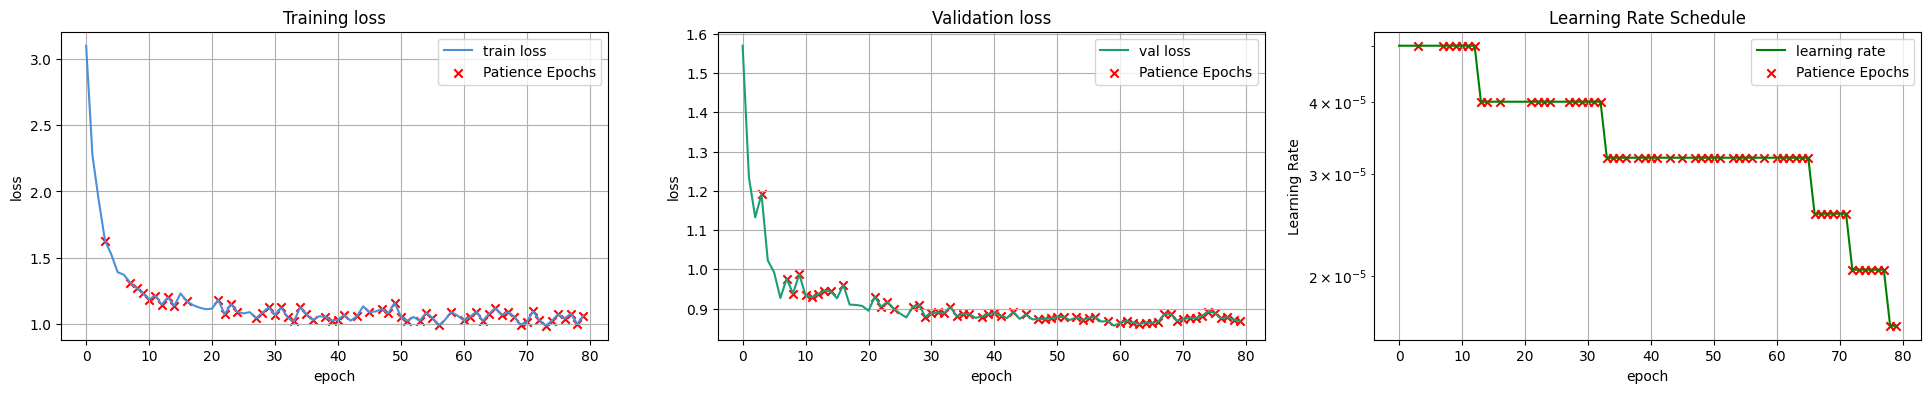

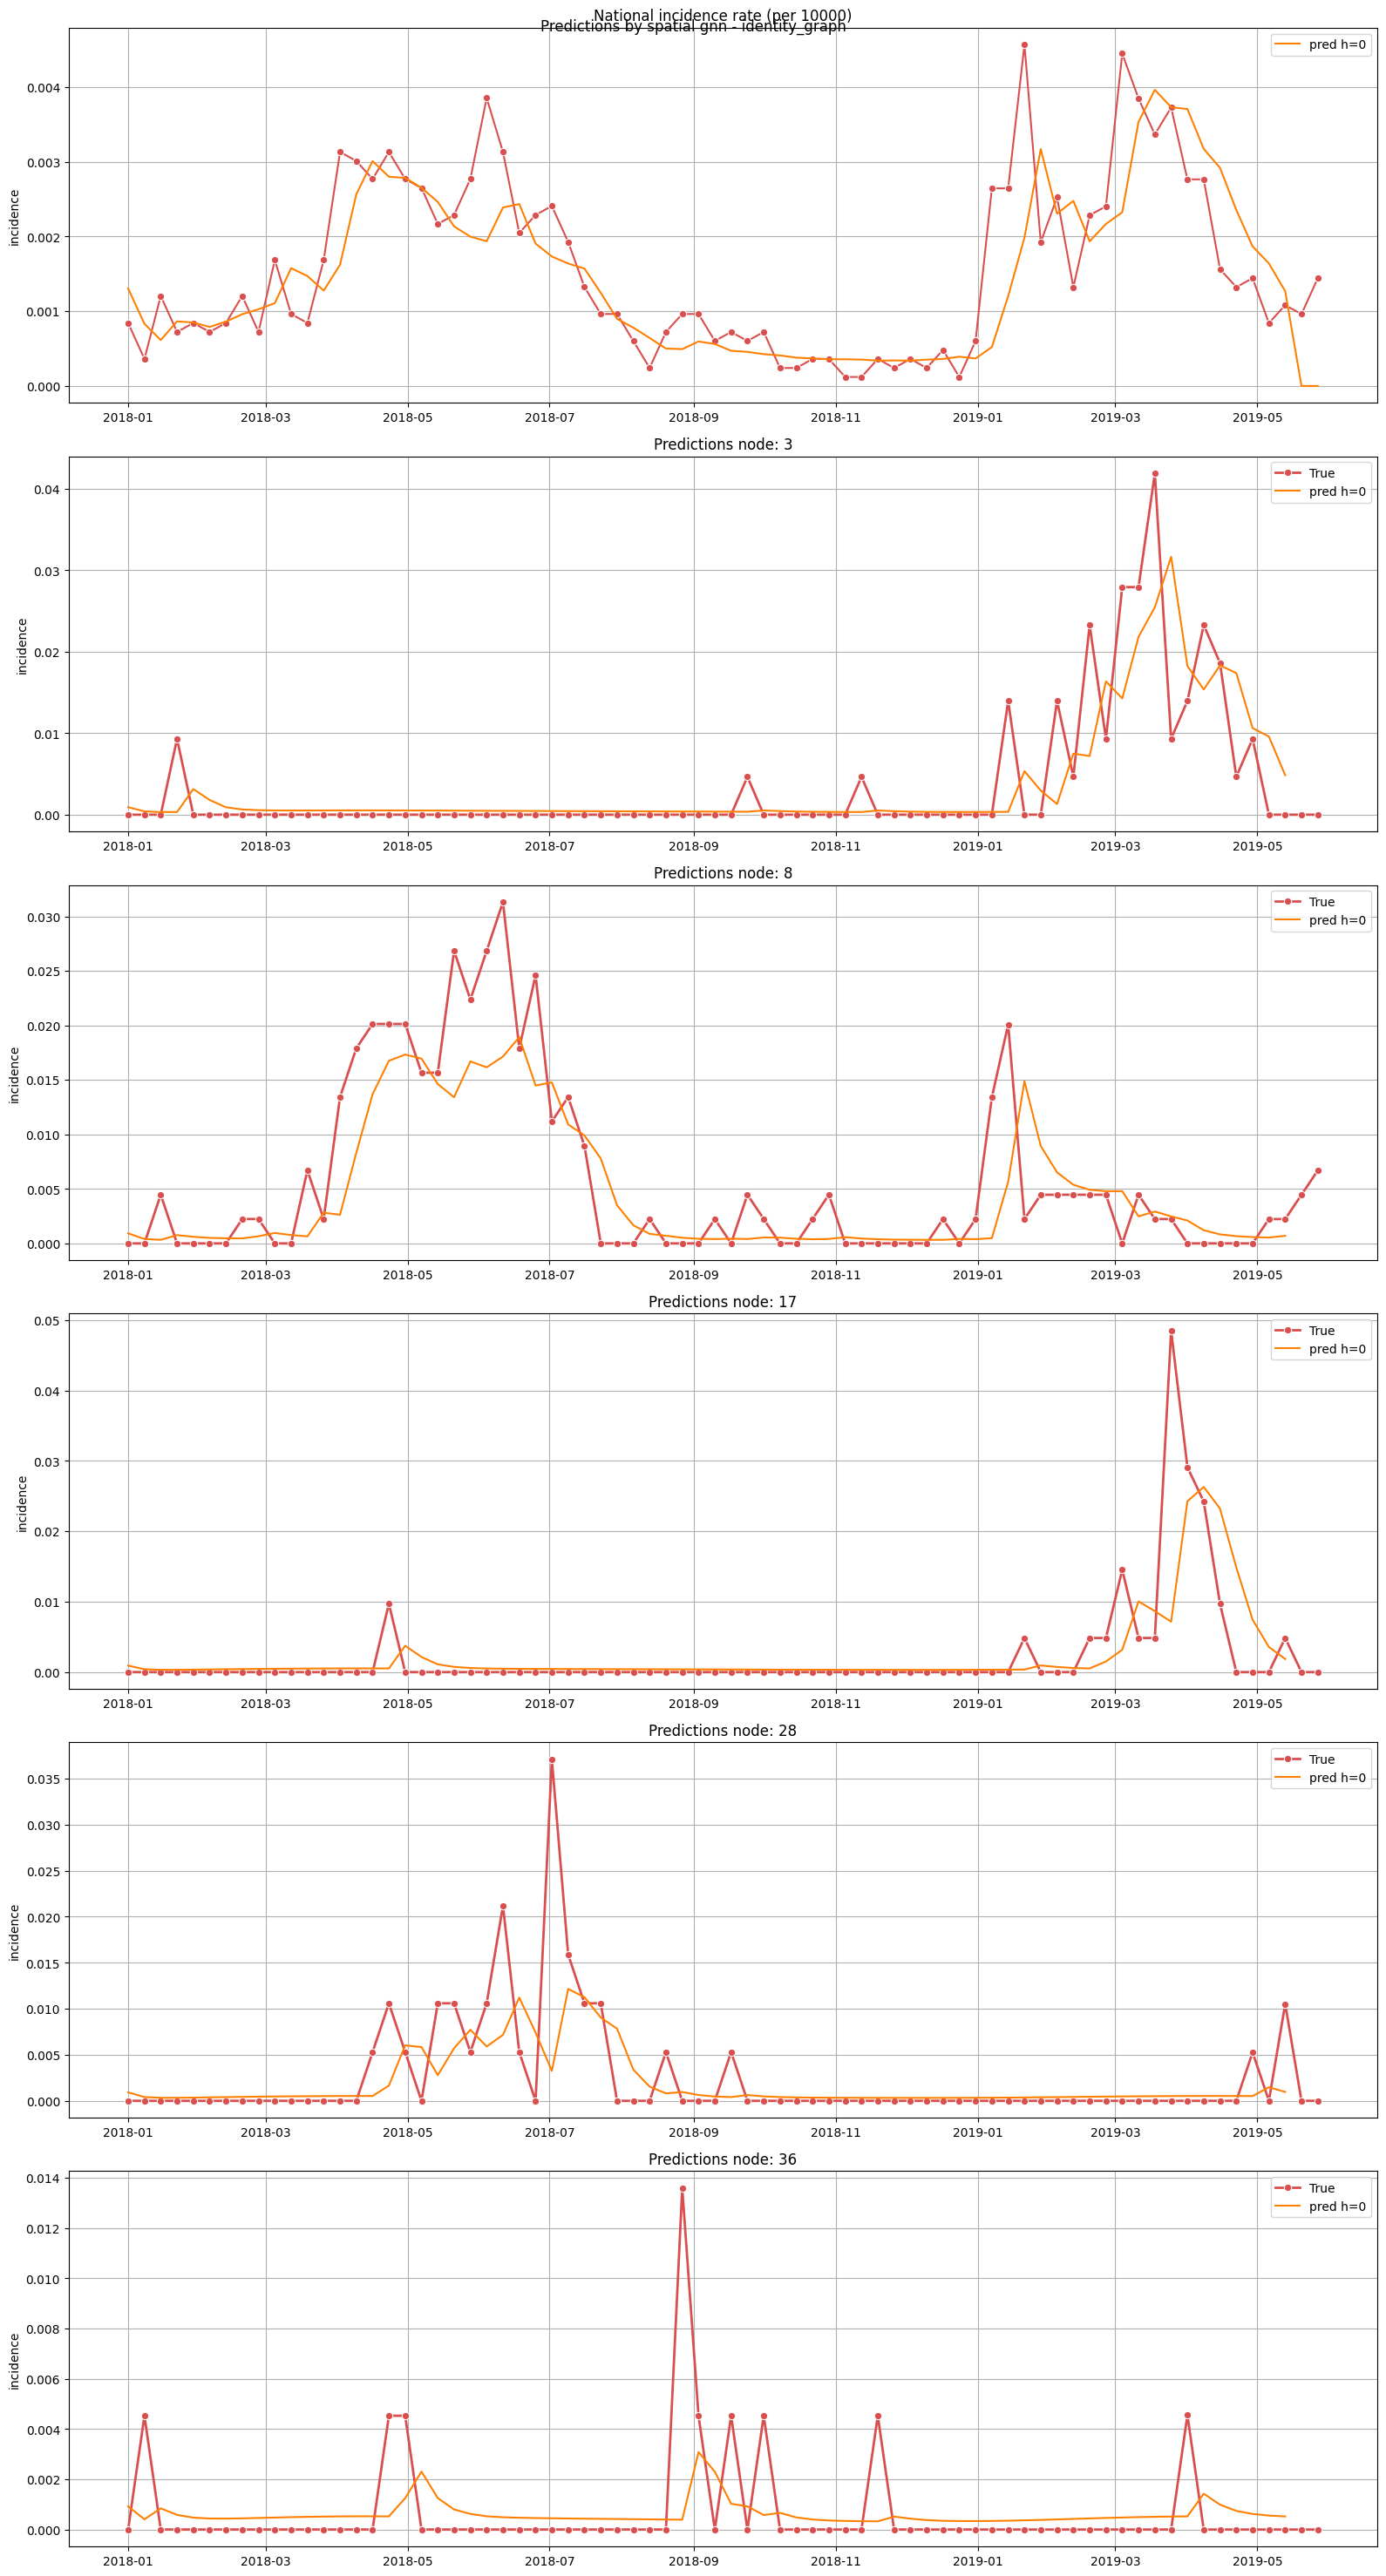

In [3]:
disease_name    = 'measles'
nuts_level      = 'nuts2'
min_date        = '2006-05-15'
max_date        = '2019-06-01'
split_trainval  = '2017-01-01'
split_valtest   = '2018-01-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 1

graphtype       = 'identity_graph'

# training hparams
n_epochs        = 150
lr              = 0.00005
min_delta       = 0
loss            = 'weighted_mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.8, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


logged_zscore = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
logged_zscore.add_time_features()
logged_zscore.log_transform_target()
logged_zscore.set_splits(split_trainval, split_valtest)
logged_zscore.normalize()
logged_zscore.add_lagged_features(lags = lags)
logged_zscore.finalize()

dl1 = logged_zscore.copy().retrieve_graph(graphtype).construct_dataloaders()


ml1      = GATv2Model(dl1, name = f'spatial gnn - {graphtype}')
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml1.forecast('test')
ml1.show_forecasts('test', measles_nodes, show_all_horizons=True)

In [13]:
ml2.forecast('train')
m12.show_forecasts('train', measles_nodes, show_all_horizons=True)

Forecasting train: 100%|███████████████████████████████████████████████████████████████████| 556/556 [00:01<00:00, 534.86it/s]

Train loss: 0.9989


NameError: name 'm12' is not defined


==Training spatial gnn - boolean_neighbors_self==
Epoch 1 train loss: 2.3600, val loss: 1.6284 ✓ (new best)
Epoch 2 train loss: 2.1019, val loss: 1.5507 ✓ (new best)
Epoch 3 train loss: 1.9035, val loss: 1.4861 ✓ (new best)
Epoch 4 train loss: 1.7583, val loss: 1.4835 ✓ (new best)
Epoch 5 train loss: 1.7669, val loss: 1.4536 ✓ (new best)
Epoch 6 train loss: 1.6440, val loss: 1.4758 (patience: 1/20)
Epoch 7 train loss: 1.6059, val loss: 1.5033 (patience: 2/20)
Epoch 8 train loss: 1.4580, val loss: 1.5408 (patience: 3/20)
Epoch 9 train loss: 1.5405, val loss: 1.5331 (patience: 4/20)
Epoch 10 train loss: 1.5018, val loss: 1.4934 (patience: 5/20)
Epoch 11 train loss: 1.4277, val loss: 1.5114 (patience: 6/20)
lr has been updated from 0.00005 to 0.00004
Epoch 12 train loss: 1.4270, val loss: 1.4601 (patience: 7/20)
Epoch 13 train loss: 1.3750, val loss: 1.4515 ✓ (new best)
Epoch 14 train loss: 1.3700, val loss: 1.4886 (patience: 1/20)
Epoch 15 train loss: 1.3818, val loss: 1.4215 ✓ (new bes

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 495.38it/s]


Test loss: 0.5408


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

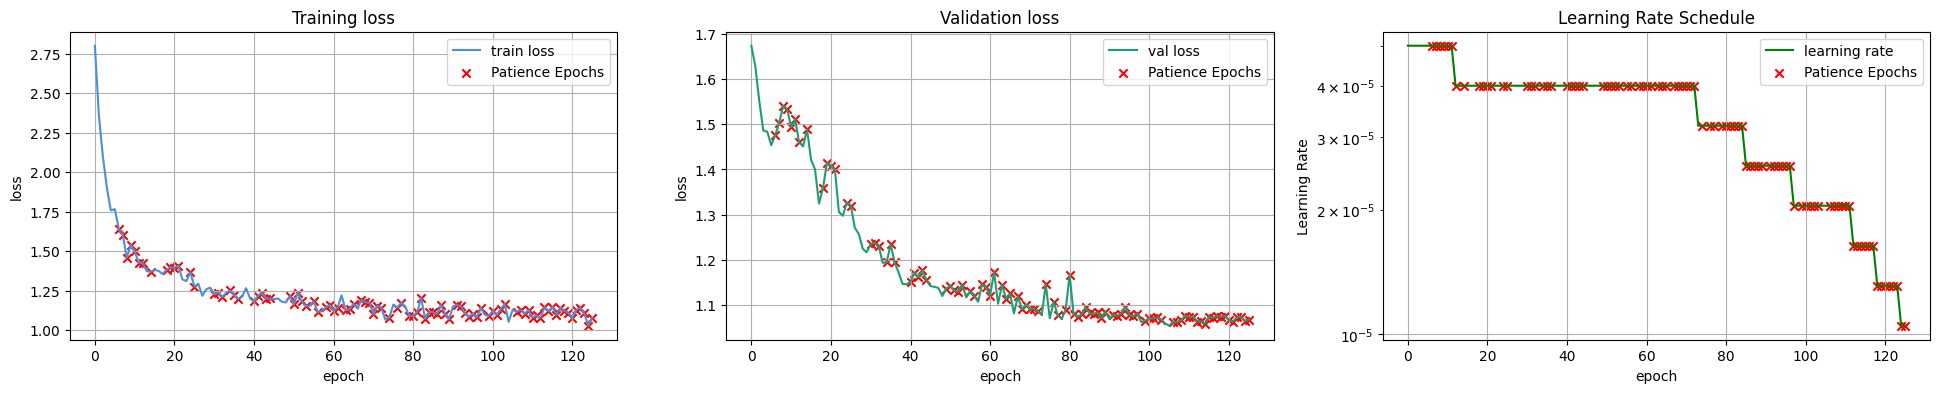

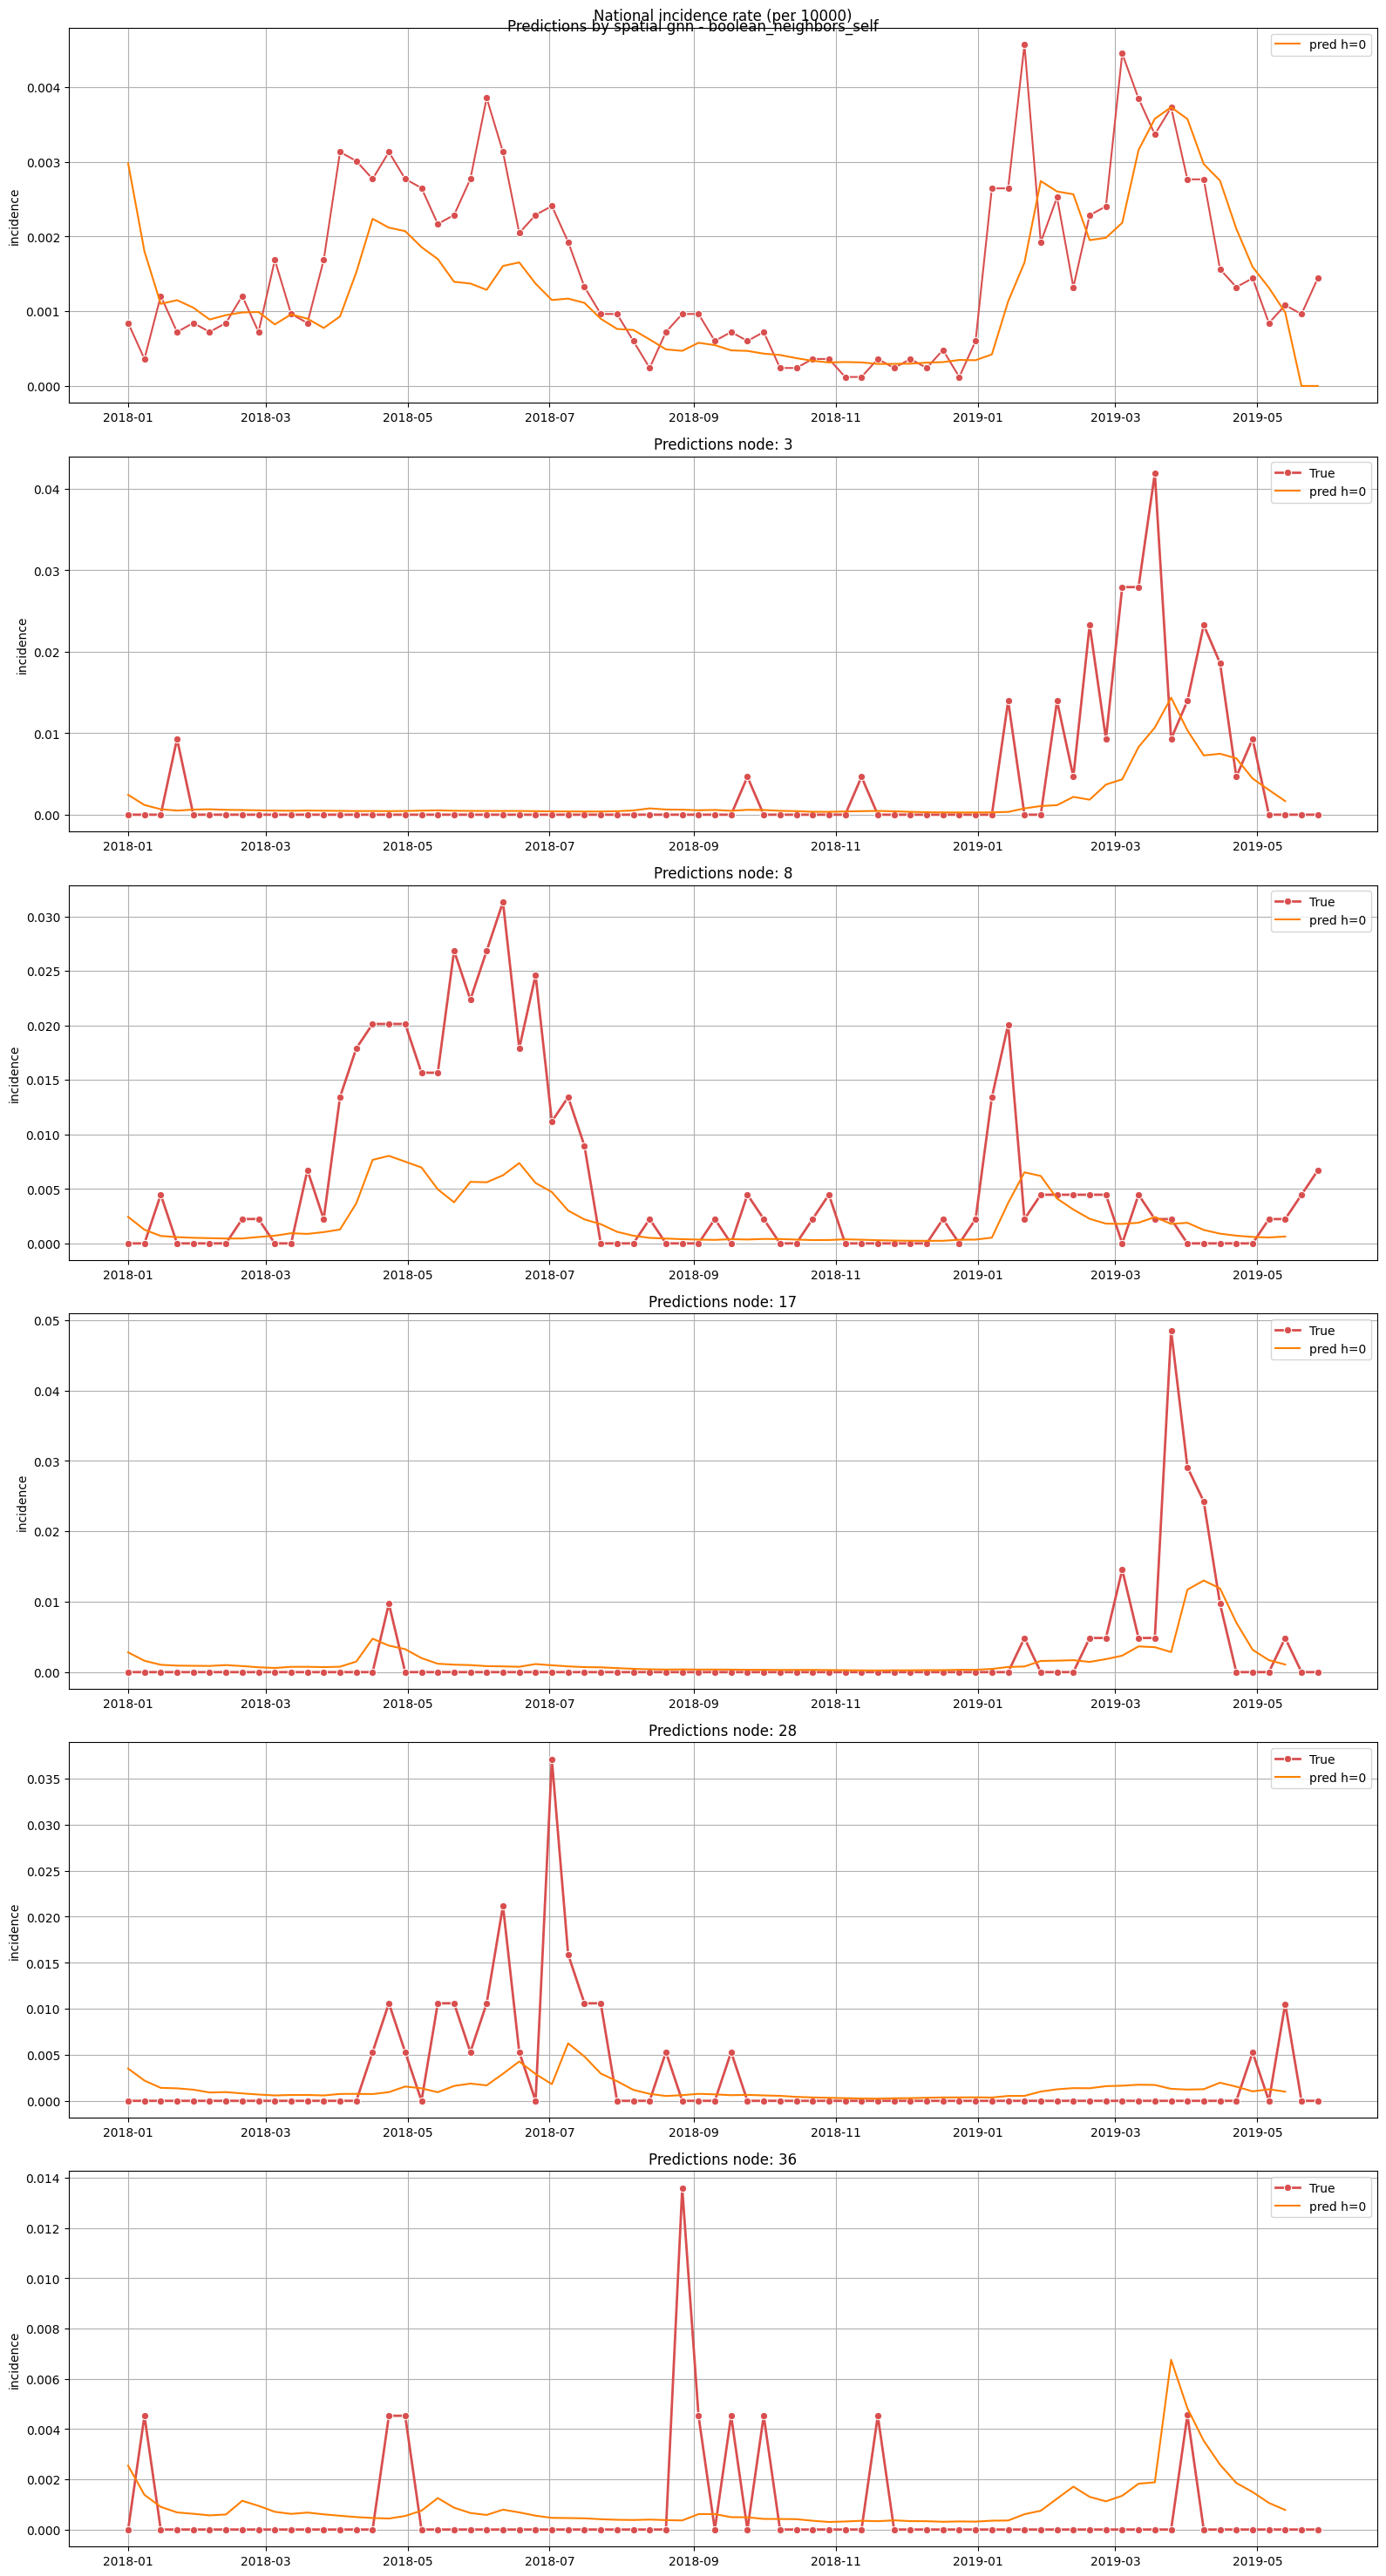

In [4]:
graphtype = 'boolean_neighbors_self'

dl2 = logged_zscore.copy().retrieve_graph(graphtype).construct_dataloaders()


ml2      = GATv2Model(dl2, name = f'spatial gnn - {graphtype}')
ml2.set_model_hparams()
ml2.set_global_hparams(**global_hparams)
ml2.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml2.forecast('test')
ml2.show_forecasts('test', measles_nodes, show_all_horizons=True)


==    Training spatial gnn - mesh     ==
Epoch 1 train loss: 2.8743, val loss: 1.8249 ✓ (new best)
Epoch 2 train loss: 2.8180, val loss: 1.8183 ✓ (new best)
Epoch 3 train loss: 2.8042, val loss: 1.8147 ✓ (new best)
Epoch 4 train loss: 2.8054, val loss: 1.8115 ✓ (new best)
Epoch 5 train loss: 2.7949, val loss: 1.8114 ✓ (new best)
Epoch 6 train loss: 2.7602, val loss: 1.8075 ✓ (new best)
Epoch 7 train loss: 2.6943, val loss: 1.8101 (patience: 1/20)
Epoch 8 train loss: 2.4681, val loss: 1.8661 (patience: 2/20)
Epoch 9 train loss: 2.1409, val loss: 5.2544 (patience: 3/20)
Epoch 10 train loss: 1.9075, val loss: 12.8536 (patience: 4/20)
Epoch 11 train loss: 1.8818, val loss: 9.6618 (patience: 5/20)
Epoch 12 train loss: 1.7553, val loss: 21.4542 (patience: 6/20)
lr has been updated from 0.00005 to 0.00004
Epoch 13 train loss: 1.7228, val loss: 20.4535 (patience: 7/20)
Epoch 14 train loss: 1.7213, val loss: 20.9484 (patience: 8/20)
Epoch 15 train loss: 1.5580, val loss: 23.6653 (patience: 9/2

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 496.27it/s]


Test loss: 1.3125


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

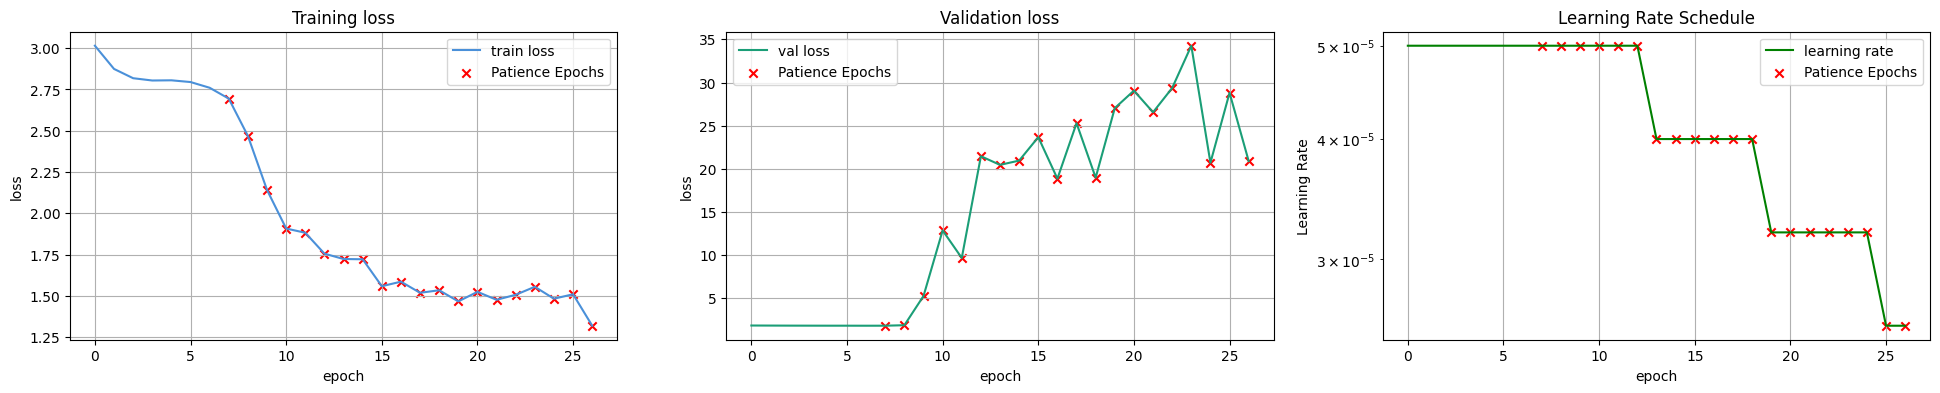

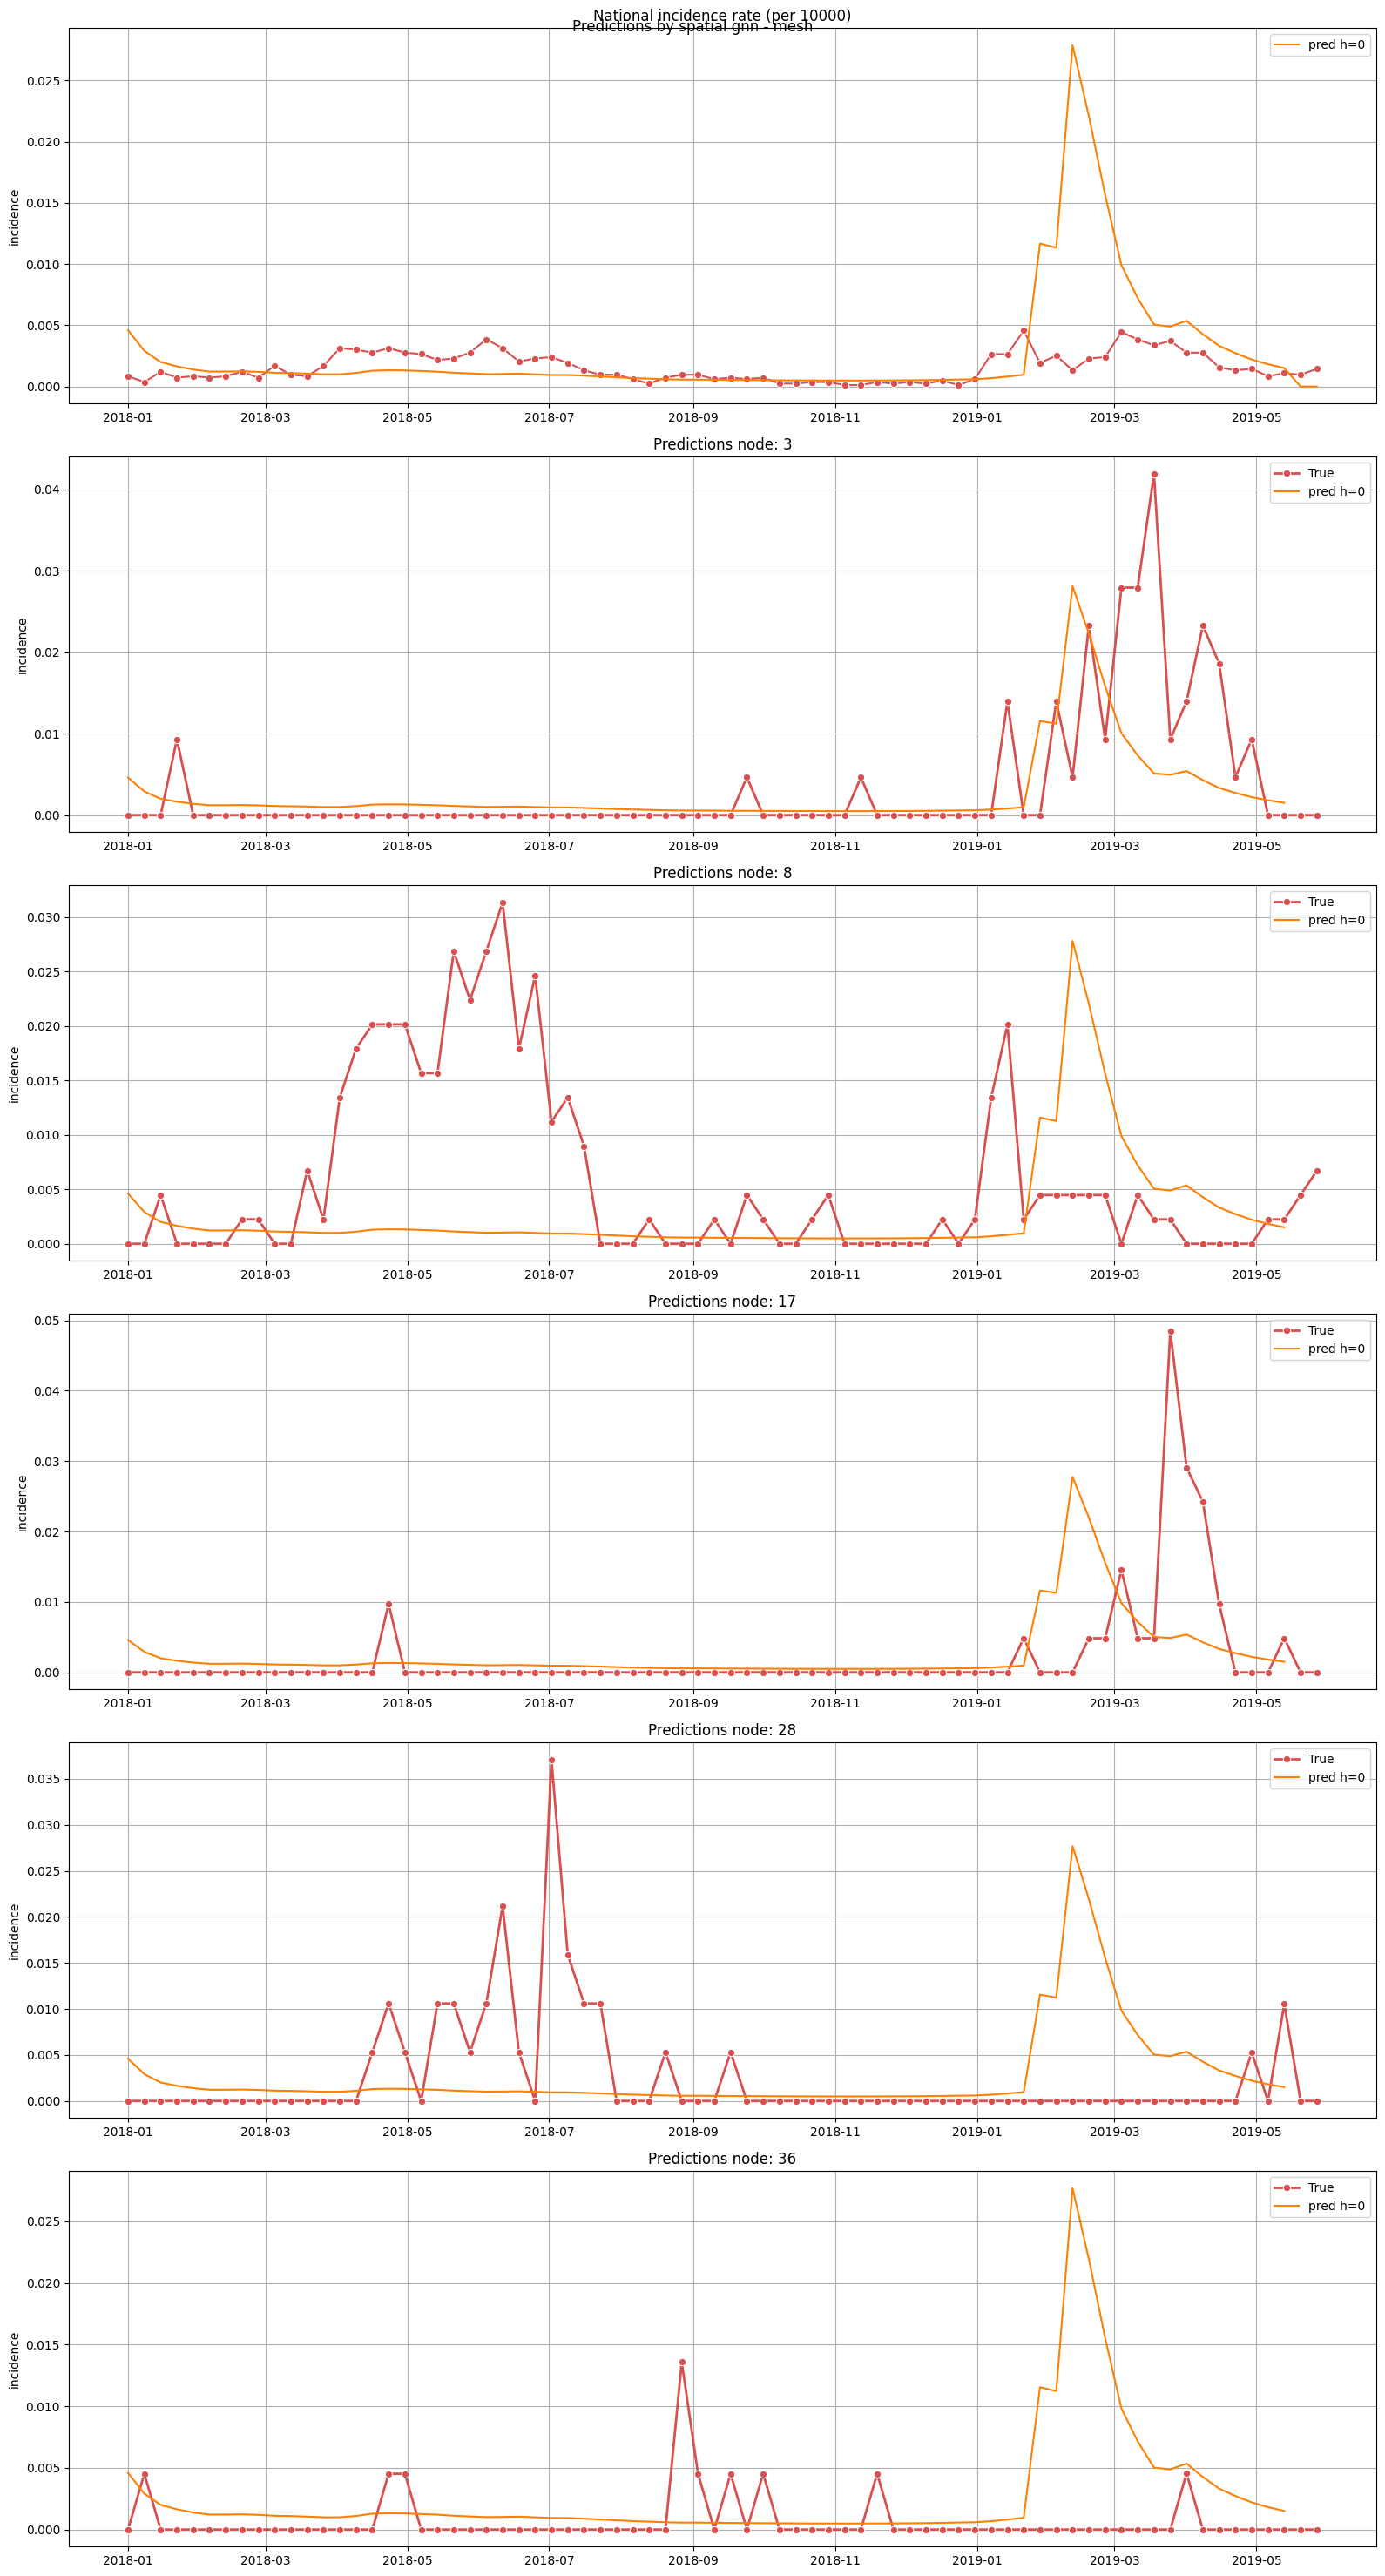

In [7]:
graphtype = 'mesh'

dl4 = logged_zscore.copy().retrieve_graph(graphtype).construct_dataloaders()


ml4      = GATv2Model(dl4, name = f'spatial gnn - {graphtype}')
ml4.set_model_hparams()
ml4.set_global_hparams(**global_hparams)
ml4.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml4.forecast('test')
ml4.show_forecasts('test', measles_nodes, show_all_horizons=True)

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

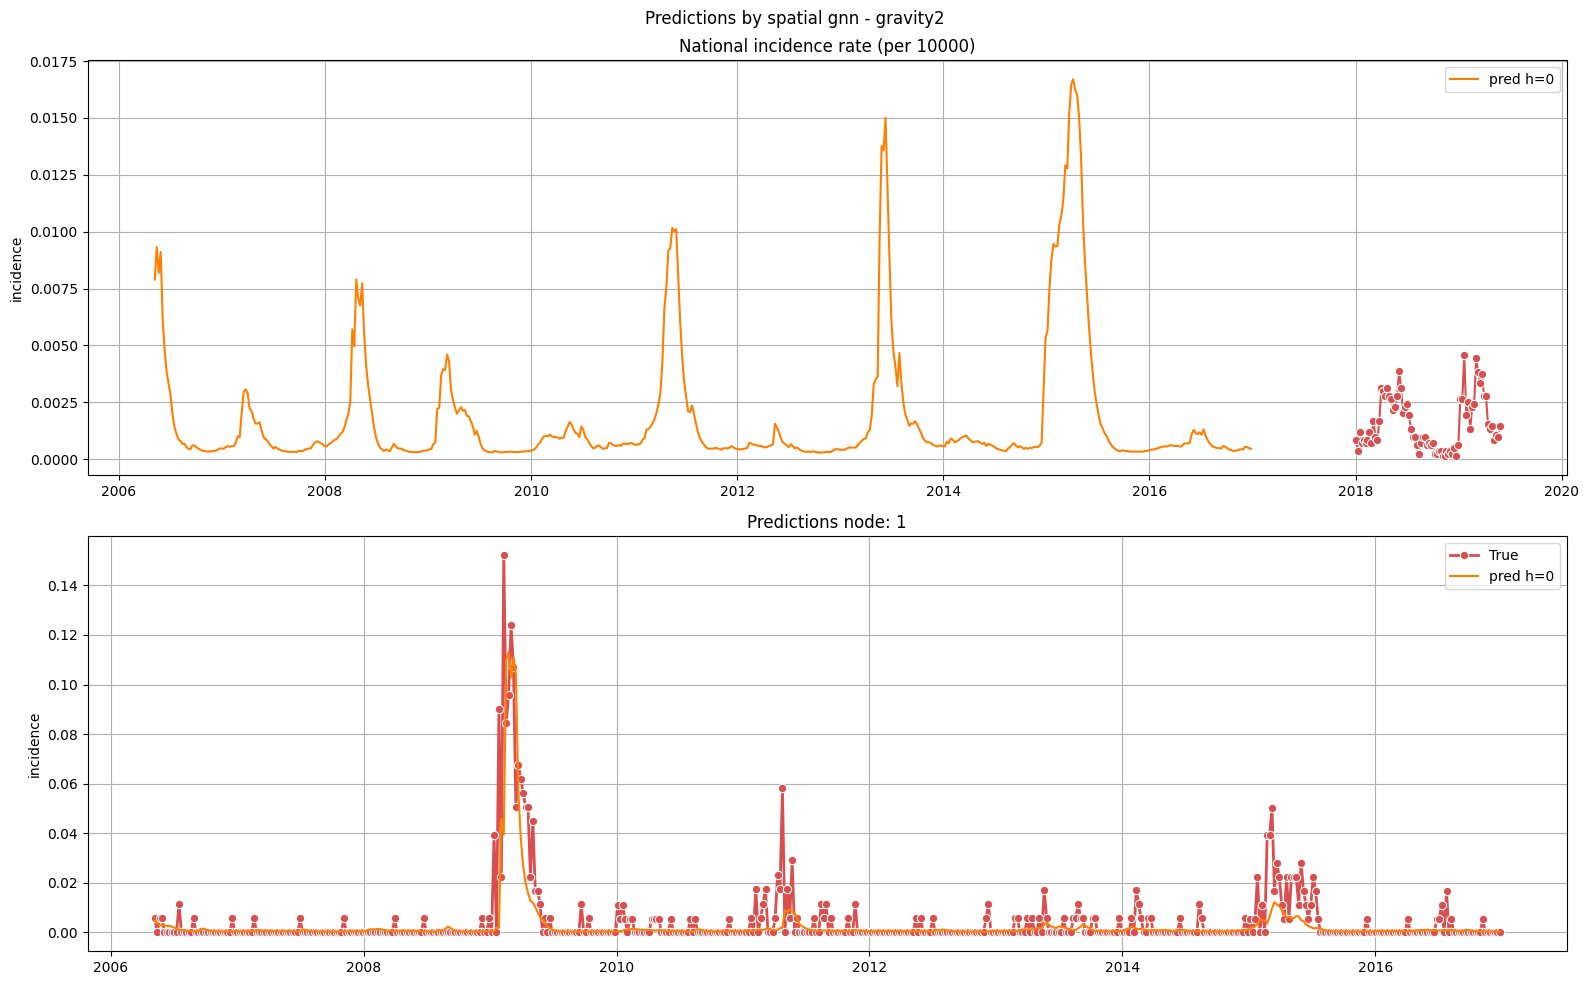

In [15]:
ml4.show_forecasts('train')


==  Training spatial gnn - gravity1   ==
Epoch 1 train loss: 2.6464, val loss: 1.7210 ✓ (new best)
Epoch 2 train loss: 2.5067, val loss: 1.7192 ✓ (new best)
Epoch 3 train loss: 2.4448, val loss: 1.6628 ✓ (new best)
Epoch 4 train loss: 2.3991, val loss: 1.5986 ✓ (new best)
Epoch 5 train loss: 2.3315, val loss: 1.5465 ✓ (new best)
Epoch 6 train loss: 2.2941, val loss: 1.5171 ✓ (new best)
Epoch 7 train loss: 2.2041, val loss: 1.4785 ✓ (new best)
Epoch 8 train loss: 2.1364, val loss: 1.4616 ✓ (new best)
Epoch 9 train loss: 2.1000, val loss: 1.4155 ✓ (new best)
Epoch 10 train loss: 2.0718, val loss: 1.4229 (patience: 1/20)
Epoch 11 train loss: 1.9889, val loss: 1.4516 (patience: 2/20)
Epoch 12 train loss: 1.9185, val loss: 1.4200 (patience: 3/20)
Epoch 13 train loss: 1.7878, val loss: 1.4323 (patience: 4/20)
Epoch 14 train loss: 1.7769, val loss: 1.5035 (patience: 5/20)
Epoch 15 train loss: 1.8507, val loss: 1.5400 (patience: 6/20)
lr has been updated from 0.00005 to 0.00004
Epoch 16 train

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 494.60it/s]


Test loss: 0.6158


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

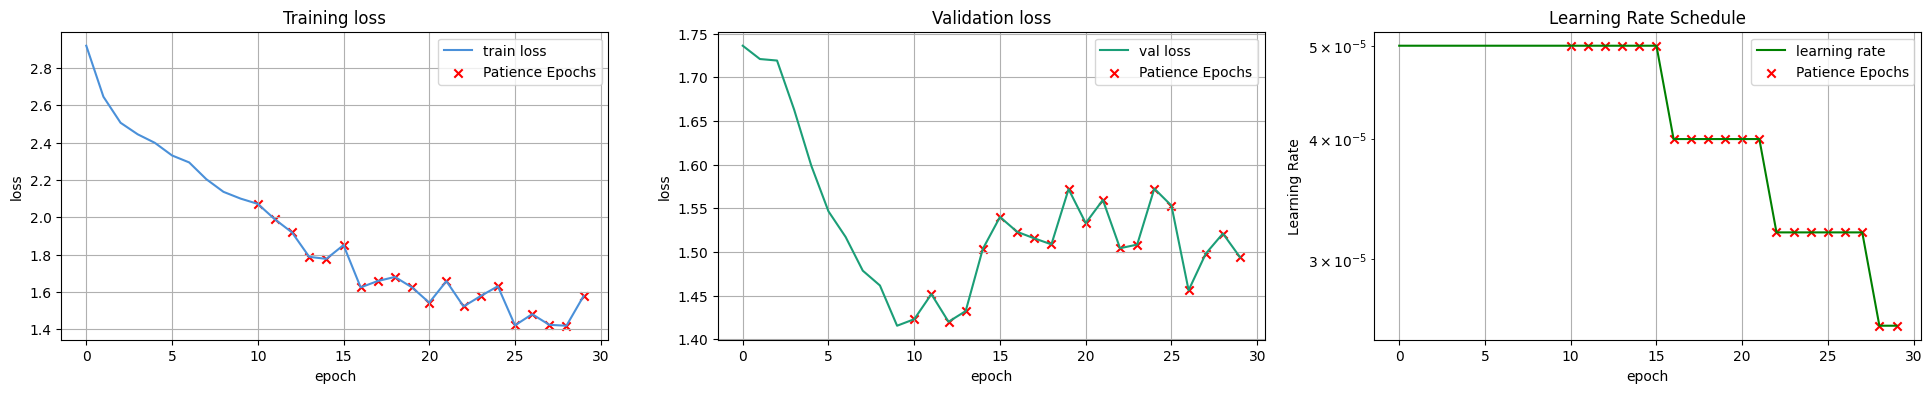

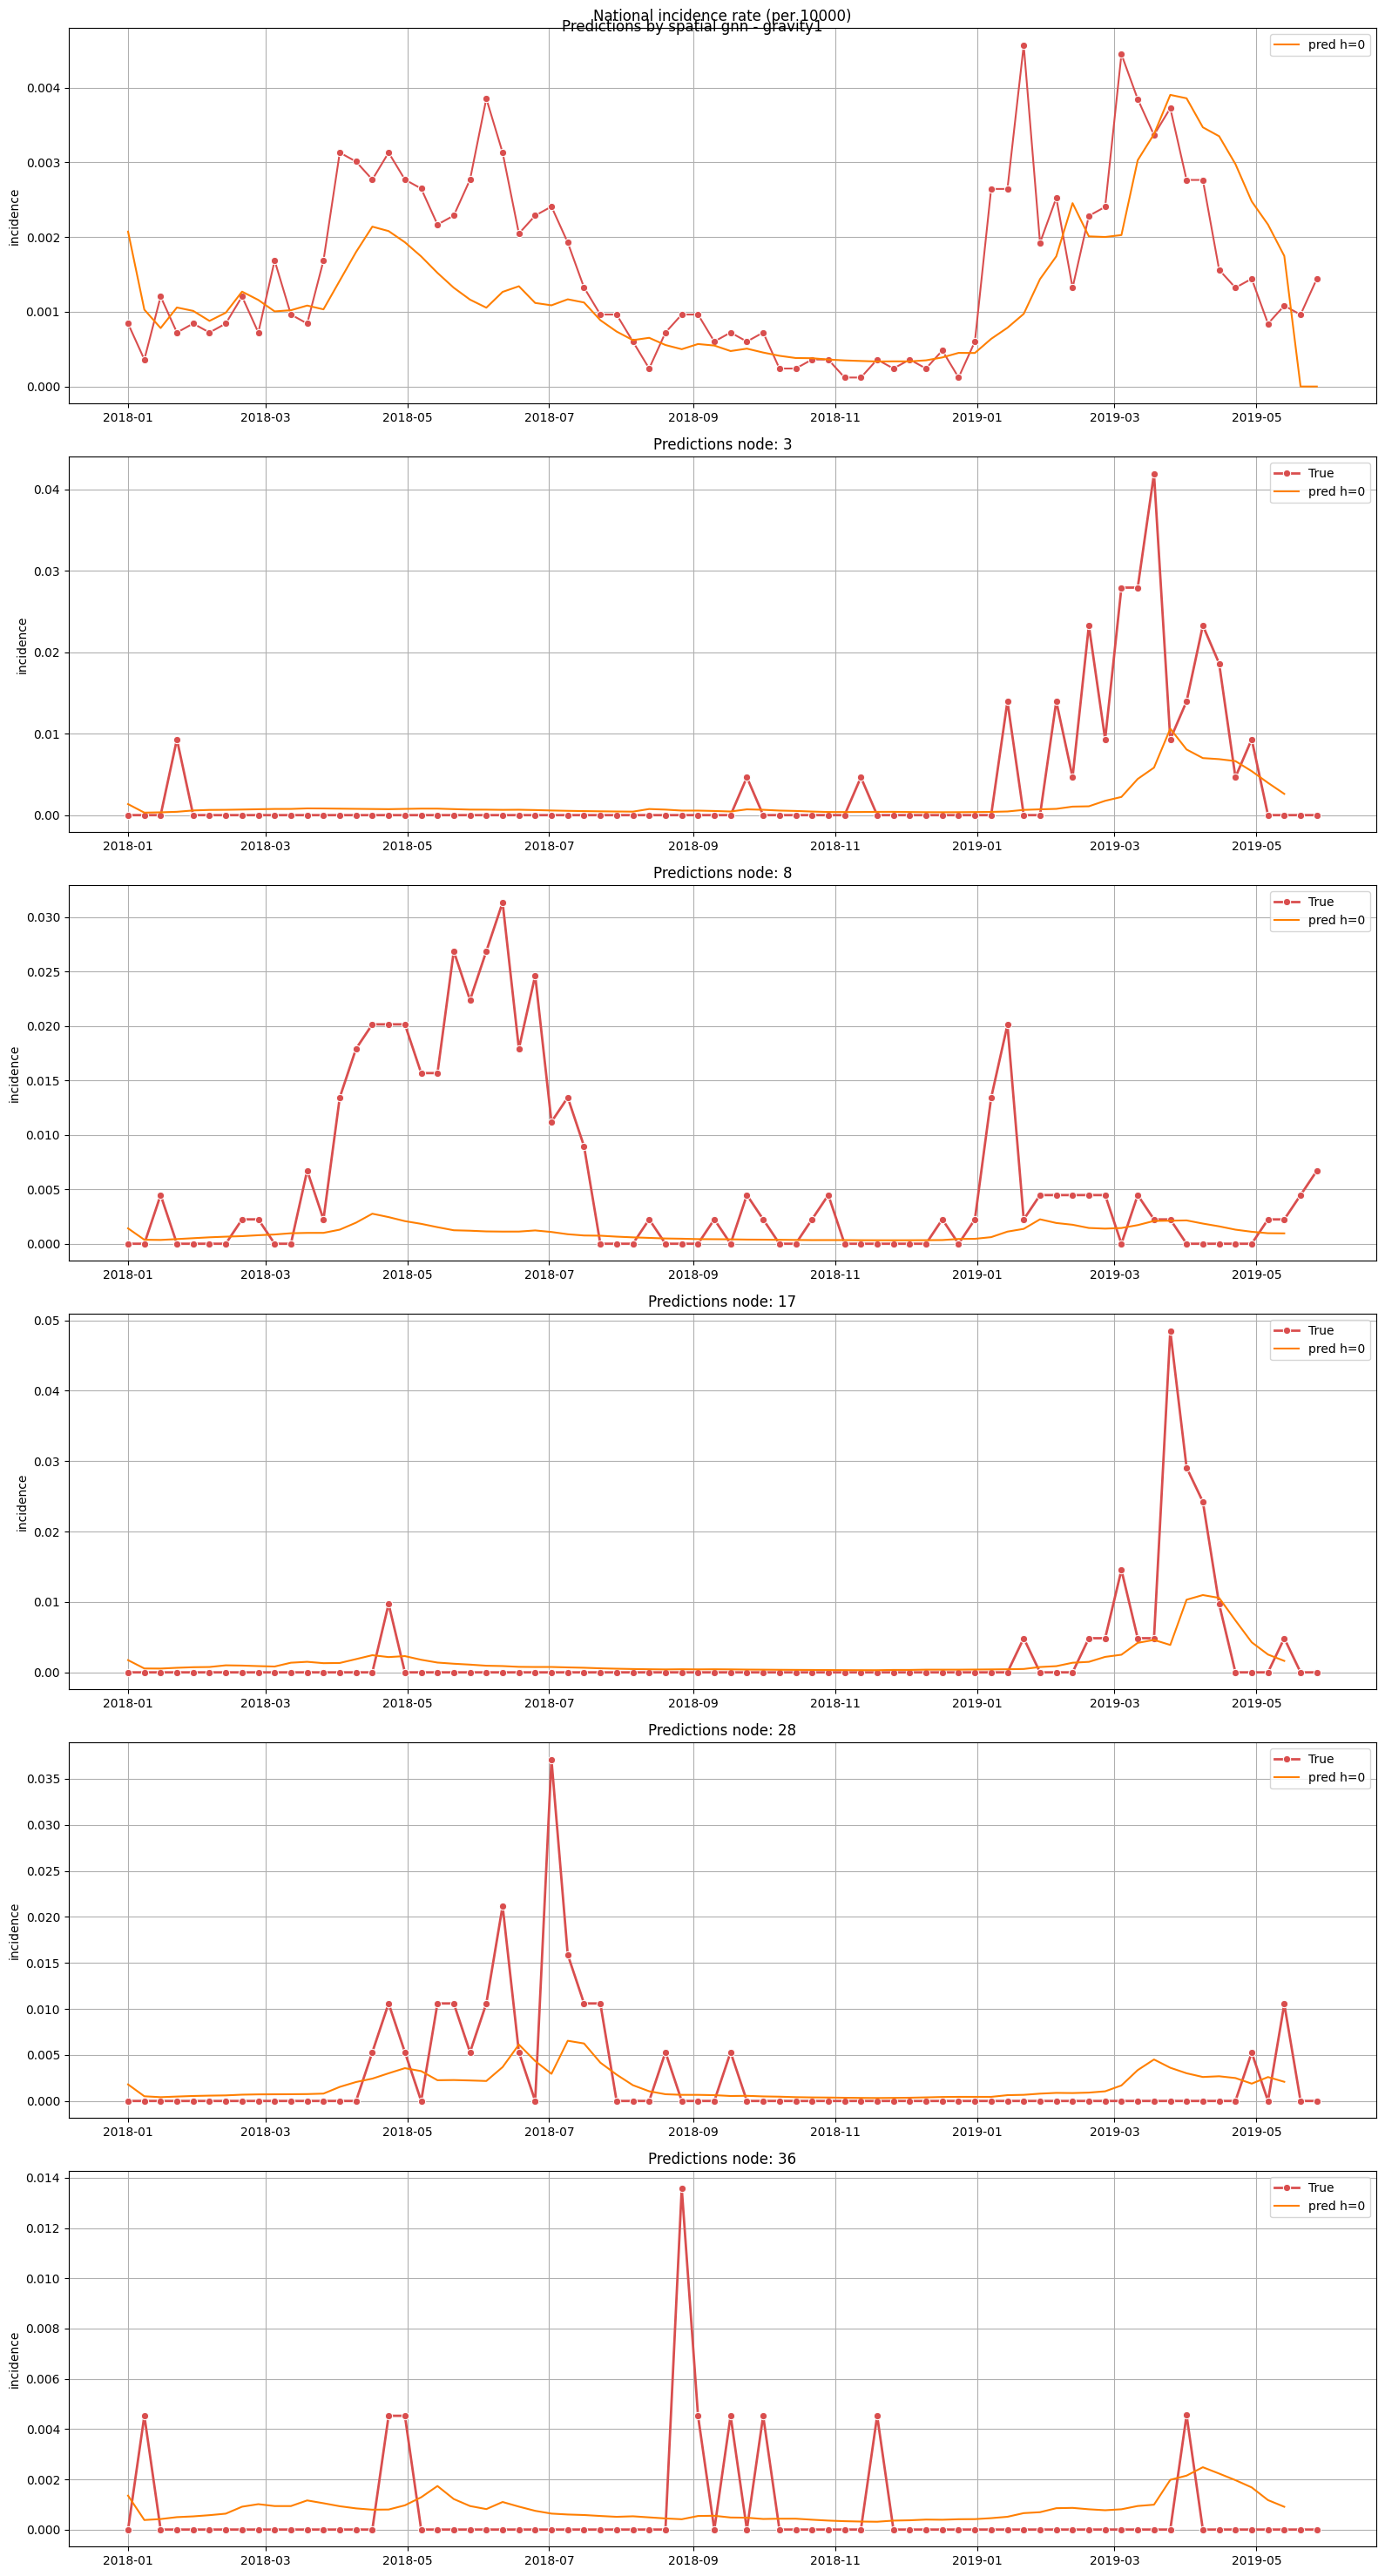

In [8]:
graphtype = 'gravity1'

dl4 = logged_zscore.copy().retrieve_graph(graphtype).construct_dataloaders()


ml4      = GATv2Model(dl4, name = f'spatial gnn - {graphtype}')
ml4.set_model_hparams()
ml4.set_global_hparams(**global_hparams)
ml4.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml4.forecast('test')
ml4.show_forecasts('test', measles_nodes, show_all_horizons=True)


==  Training spatial gnn - gravity2   ==
Epoch 1 train loss: 2.7509, val loss: 1.7572 ✓ (new best)
Epoch 2 train loss: 2.6161, val loss: 1.7578 (patience: 1/20)
Epoch 3 train loss: 2.5791, val loss: 1.7355 ✓ (new best)
Epoch 4 train loss: 2.4860, val loss: 1.7132 ✓ (new best)
Epoch 5 train loss: 2.4130, val loss: 1.7233 (patience: 1/20)
Epoch 6 train loss: 2.3640, val loss: 1.7378 (patience: 2/20)
Epoch 7 train loss: 2.3553, val loss: 1.7163 (patience: 3/20)
Epoch 8 train loss: 2.2927, val loss: 1.6756 ✓ (new best)
Epoch 9 train loss: 2.2515, val loss: 1.6555 ✓ (new best)
Epoch 10 train loss: 2.1455, val loss: 1.5926 ✓ (new best)
Epoch 11 train loss: 2.0778, val loss: 1.5081 ✓ (new best)
Epoch 12 train loss: 2.0582, val loss: 1.6551 (patience: 1/20)
Epoch 13 train loss: 1.8646, val loss: 1.6346 (patience: 2/20)
Epoch 14 train loss: 1.7626, val loss: 1.5832 (patience: 3/20)
Epoch 15 train loss: 1.6345, val loss: 1.6550 (patience: 4/20)
Epoch 16 train loss: 1.7814, val loss: 1.6066 (pat

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 493.38it/s]


Test loss: 0.6049


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

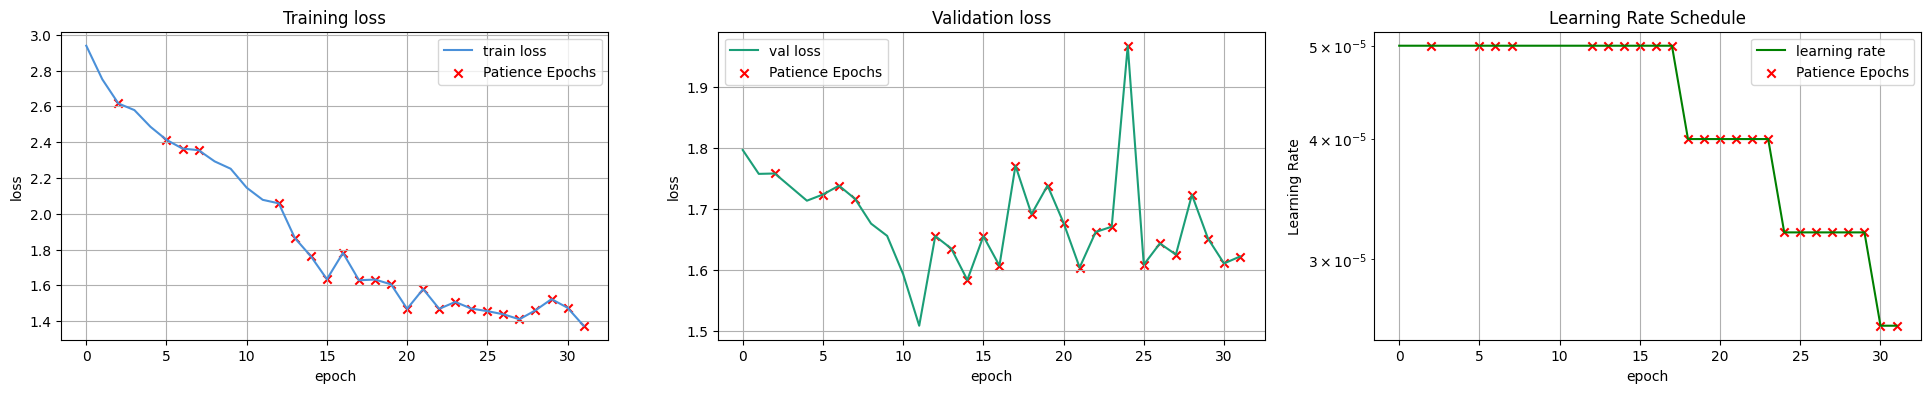

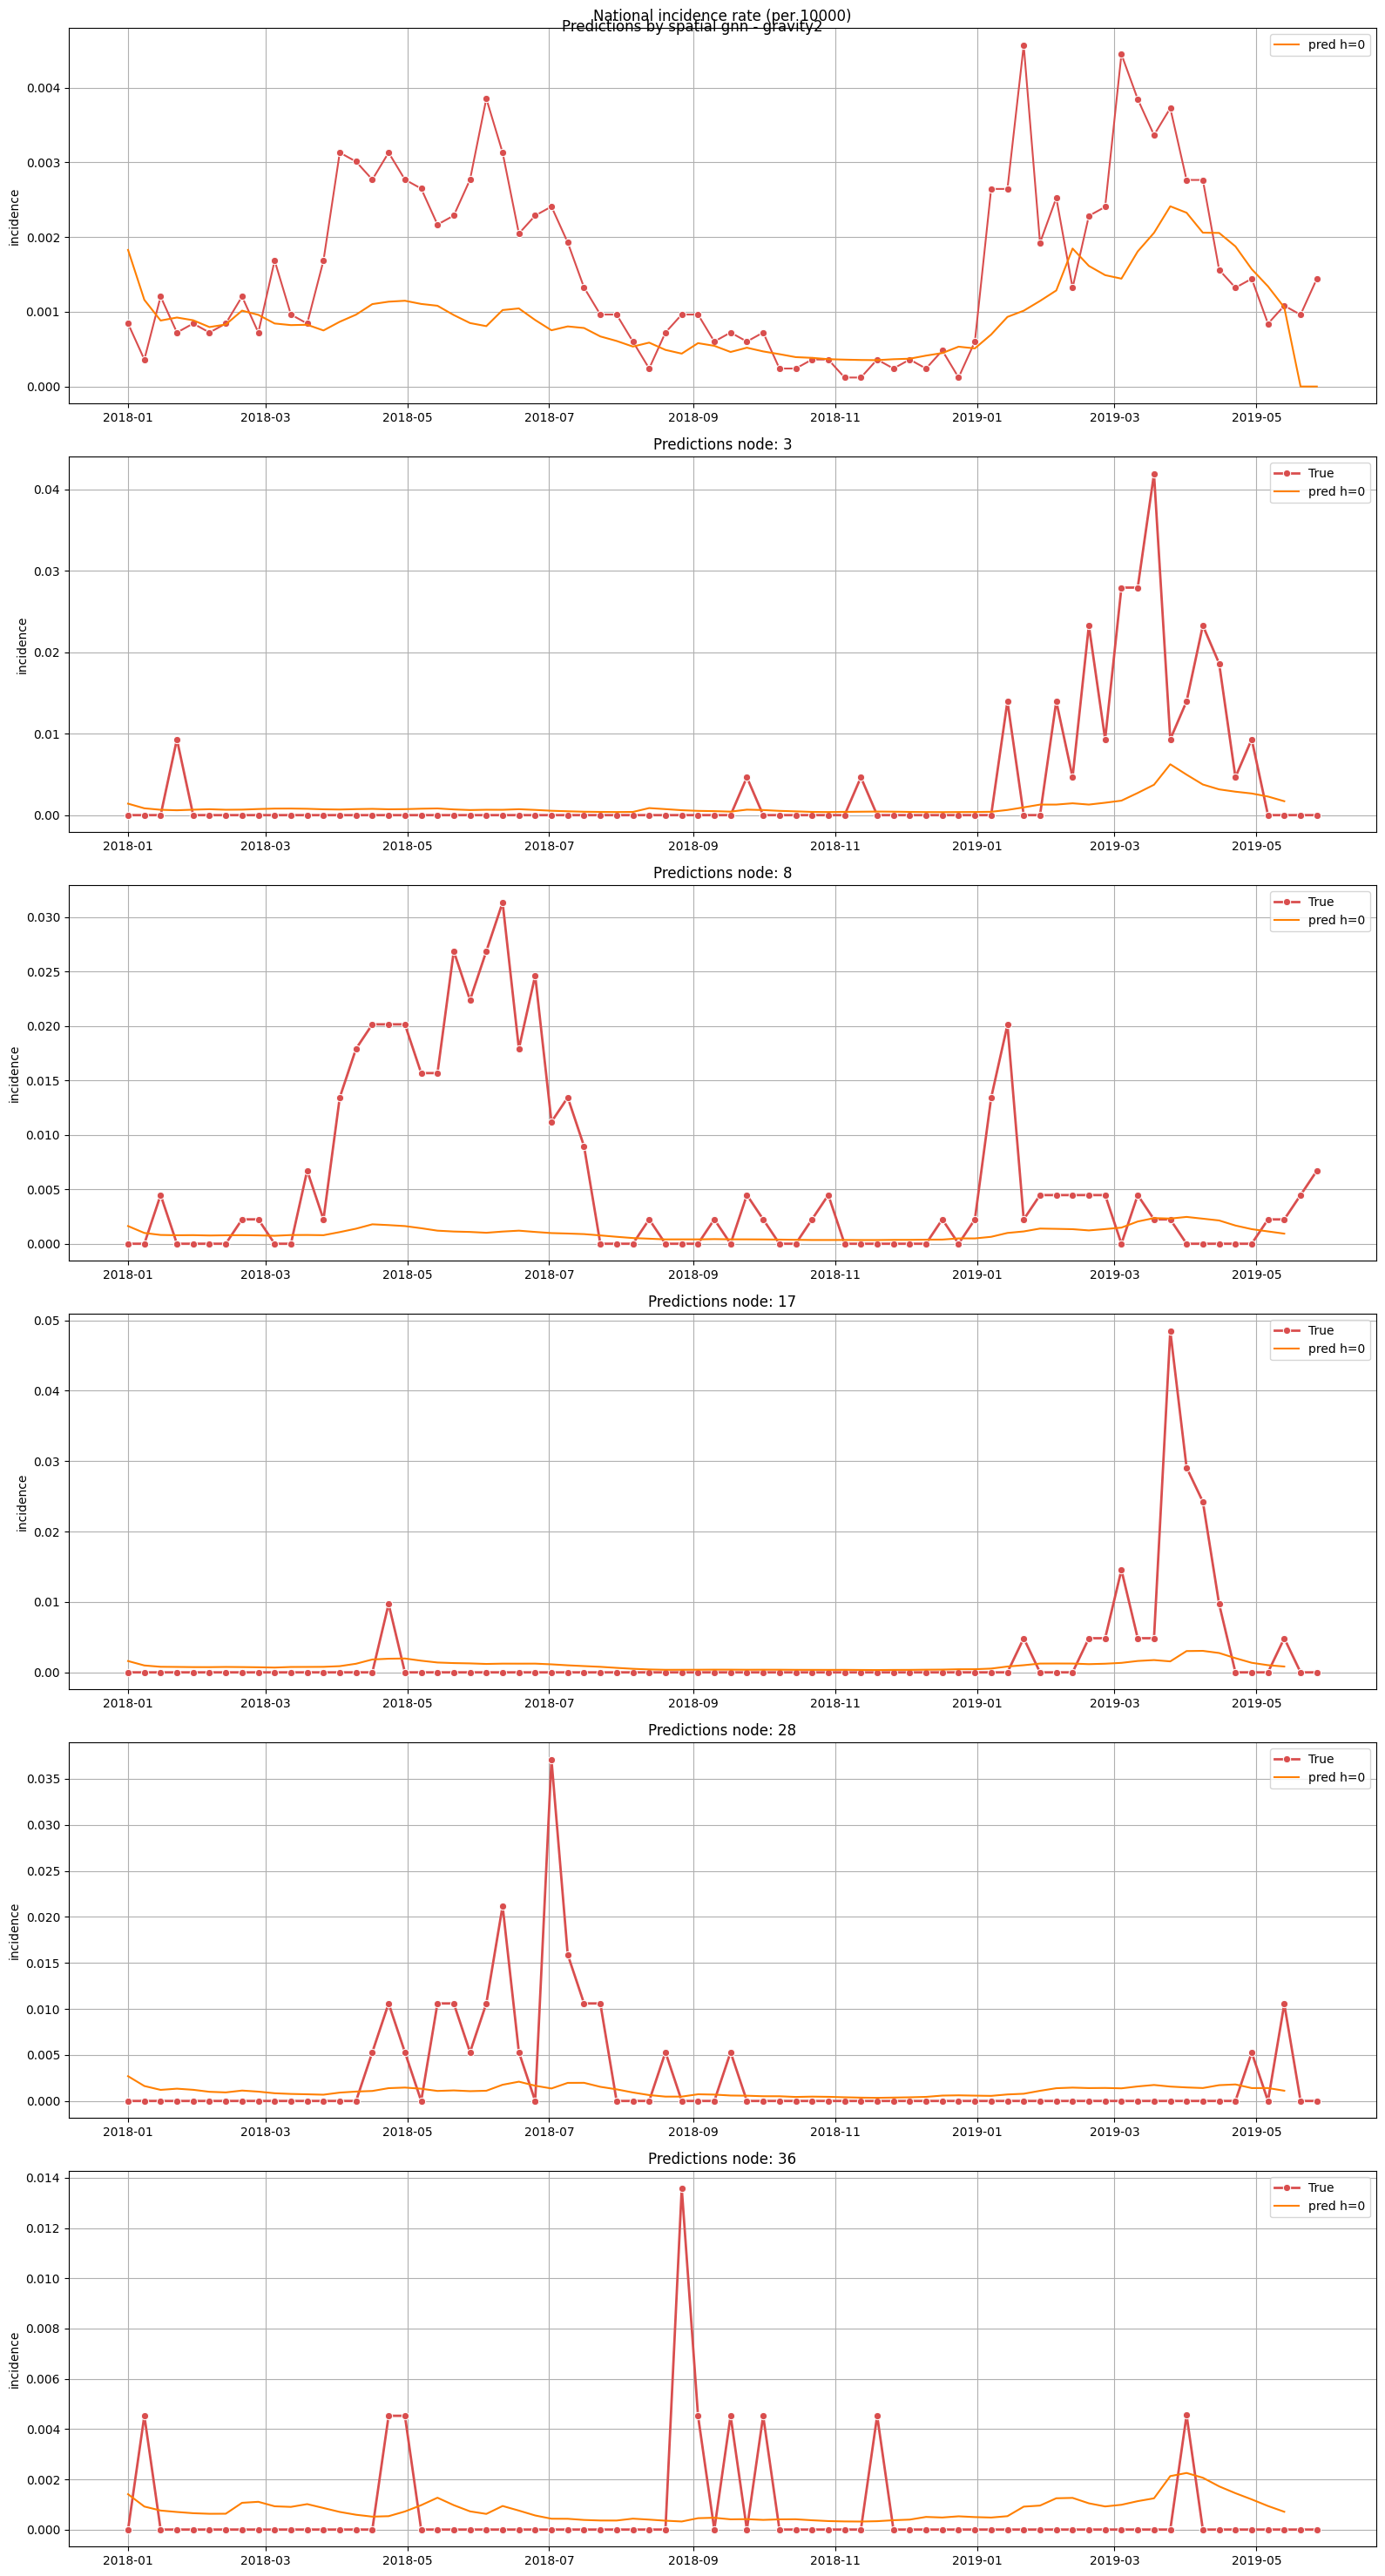

In [9]:
graphtype = 'gravity2'

dl4 = logged_zscore.copy().retrieve_graph(graphtype).construct_dataloaders()


ml4      = GATv2Model(dl4, name = f'spatial gnn - {graphtype}')
ml4.set_model_hparams()
ml4.set_global_hparams(**global_hparams)
ml4.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml4.forecast('test')
ml4.show_forecasts('test', measles_nodes, show_all_horizons=True)